In [2]:
import pandas as pd
import numpy as np
import os
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from scipy.stats import pearsonr

import geopandas as gpd
from shapely.geometry import Point
from geopandas import GeoDataFrame
from geopy.distance import geodesic
from datetime import date, timedelta

In [ ]:
################## Combined gridMET Data ##################

In [5]:
gridMET_data = pd.read_csv("/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/gridMET.csv")

In [6]:
gridMET_data.columns

Index(['id2', 'year', 'yield', 'tmmx-10-04', 'tmmx-11-04', 'tmmx-12-04',
       'tmmx-13-04', 'tmmx-14-04', 'tmmx-15-04', 'tmmx-16-04',
       ...
       'th-27-10', 'th-28-10', 'th-29-10', 'th-30-10', 'th-31-10', 'th-01-11',
       'th-02-11', 'th-03-11', 'th-04-11', 'th-05-11'],
      dtype='object', length=3363)

In [ ]:
###### Adding county names

In [49]:
cbelt_shapefile = gpd.read_file("/Users/guptsh/Downloads/Soil_Land_Crop/datasets/Shape-files/CornBeltShapefiles/CornBeltCounty.shp")

In [50]:
cbelt_shapefile.shape

(1443, 13)

In [51]:
cbelt_shapefile.columns

Index(['ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'ID_2', 'NAME_2', 'TYPE_2',
       'ENGTYPE_2', 'NL_NAME_2', 'VARNAME_2', 'Area', 'geometry'],
      dtype='object')

In [52]:
gridMET_data = gridMET_data.merge(cbelt_shapefile[['ID_2', 'NAME_2']], 
                                  left_on='id2', 
                                  right_on='ID_2', 
                                  how='left')
gridMET_data.drop(columns=['ID_2'], inplace=True)
gridMET_data.rename(columns={'NAME_2': 'Counties'}, inplace=True)

In [64]:
gridMET_data.shape

(45338, 3364)

In [ ]:
###### Adding FIPS code (not working right currently)

In [42]:
us_shapefile = gpd.read_file("/Users/shrey/Downloads/Soil_Land_Crop/datasets/Shape-files/cb_2018_us_county_5m/cb_2018_us_county_5m.shp")

In [43]:
us_shapefile.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME', 'LSAD',
       'ALAND', 'AWATER', 'geometry'],
      dtype='object')

In [44]:
gridMET_data['Counties'] = gridMET_data['Counties'].str.lower()
us_shapefile['NAME'] = us_shapefile['NAME'].str.lower()

gridMET_data = gridMET_data.merge(us_shapefile[['NAME', 'COUNTYFP']], 
                                  left_on='Counties', 
                                  right_on='NAME', 
                                  how='left')

gridMET_data.drop(columns=['NAME'], inplace=True)

In [45]:
new_column_order = ['Counties', 'COUNTYFP', 'id2', 'year', 'yield'] + \
                   [col for col in gridMET_data.columns if col not in ['Counties', 'COUNTYFP', 'id2', 'year', 'yield']]

gridMET_data = gridMET_data[new_column_order]

In [57]:
gridMET_data.columns

Index(['id2', 'year', 'yield', 'tmmx-10-04', 'tmmx-11-04', 'tmmx-12-04',
       'tmmx-13-04', 'tmmx-14-04', 'tmmx-15-04', 'tmmx-16-04',
       ...
       'th-28-10', 'th-29-10', 'th-30-10', 'th-31-10', 'th-01-11', 'th-02-11',
       'th-03-11', 'th-04-11', 'th-05-11', 'Counties'],
      dtype='object', length=3364)

In [ ]:
################## Fertilizer Data ##################

In [4]:
fertilizer_data = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/y_geo_fert_soil_1980_rawyield.csv")

In [55]:
fertilizer_data = fertilizer_data.drop(columns=['Unnamed: 0', 'id'])

In [63]:
fertilizer_data.shape

(43528, 105)

In [61]:
merged_data = gridMET_data.merge(fertilizer_data, on=['id2', 'year'], how='inner')
merged_data = merged_data.loc[:, ~merged_data.columns.duplicated()]

In [62]:
merged_data

,id2,year,yield_x,tmmx-10-04,tmmx-11-04,tmmx-12-04,tmmx-13-04,tmmx-14-04,tmmx-15-04,tmmx-16-04,...,S_78,S_79,S_80,S_81,S_82,S_83,S_84,S_85,S_86,S_87
0,112,1980,27.0,297.150746,288.676866,286.200000,282.085821,294.295522,296.445522,294.279851,...,-0.019864,-0.218310,-0.190130,0.808602,-0.196895,-0.020476,-0.159659,-0.709590,-0.019864,-0.016271
1,113,1980,28.0,297.274444,288.907778,285.003333,280.973333,293.290000,294.762222,293.843333,...,-0.019864,-0.218310,-0.190130,0.808602,-0.196895,-0.020476,-0.159659,-0.709590,-0.019864,-0.016271
2,119,1980,29.0,295.384158,290.352475,283.873267,281.912871,292.167327,292.957426,295.866337,...,-0.019864,-0.218310,-0.190130,0.808602,-0.196895,-0.020476,-0.159659,-0.709590,-0.019864,-0.016271
3,120,1980,28.0,296.932727,290.636364,282.992727,282.347273,293.369091,295.369091,294.618182,...,-0.019864,-0.218310,-0.190130,0.808602,-0.196895,-0.020476,-0.159659,-0.709590,-0.019864,-0.016271
4,124,1980,24.0,295.936275,290.024510,283.841176,282.185294,292.311765,294.537255,296.009804,...,-0.019864,-0.218310,-0.190130,0.808602,-0.196895,-0.020476,-0.159659,-0.709590,-0.019864,-0.016271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43523,652,2017,230.7,287.294915,293.603390,295.508475,298.940678,300.432203,295.216949,296.330508,...,-0.019864,-0.218310,1.083974,-0.370021,-0.196895,-0.020476,-0.159659,0.491840,-0.019864,-0.016271
43524,653,2017,201.8,289.553409,294.496591,300.420455,300.552273,301.125000,295.240909,295.195455,...,-0.019864,2.564034,-0.190130,-1.464457,-0.196895,-0.020476,-0.159659,1.607455,-0.019864,-0.016271
43525,654,2017,178.8,292.494737,297.157895,301.378947,302.342105,301.418421,299.889474,292.610526,...,-0.019864,-0.218310,-0.190130,-0.454209,-0.196895,-0.020476,-0.159659,0.577657,-0.019864,-0.016271
43526,655,2017,221.8,289.009091,295.177273,299.209091,297.706818,300.389773,295.071591,295.503409,...,-0.019864,-0.218310,-0.190130,-1.043520,-0.196895,-0.020476,-0.159659,1.178372,-0.019864,-0.016271


In [ ]:
################## Crop Yield Data ##################

In [155]:
gridMET_labels = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/label_1980_2018_rawyield.csv")
# gridMET_labels = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/label_1980_2018_rawyield.csv", index_col = 'index')

In [157]:
gridMET_labels = gridMET_labels[['id2', 'year', 'yield']]

In [166]:
gridMET_labels.columns

,id2,year,yield
0,112,1980,27.0
1,113,1980,28.0
2,119,1980,29.0
3,120,1980,28.0
4,124,1980,24.0
...,...,...,...
45333,3121,2018,182.0
45334,3122,2018,156.8
45335,3123,2018,163.4
45336,3124,2018,160.4


In [163]:
gridMET_labels_17 = gridMET_labels[gridMET_labels['year'] == 2017]
gridMET_labels_17 = gridMET_labels_17.reset_index(drop = True)

In [167]:
gridMET_labels_17.columns

Index(['id2', 'year', 'yield'], dtype='object')

In [165]:
### Calculating yield and ID counts
yield_counts = gridMET_labels.groupby('year')['yield'].count()
id_counts = gridMET_labels.groupby('year')['id2'].count()

In [ ]:
############## Met feature data

In [65]:
X_bi = np.load('/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/X_bi_1980_2018_rawyield', allow_pickle=True)
X_erc = np.load('/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/X_erc_1980_2018_rawyield', allow_pickle=True)
X_etr = np.load('/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/X_etr_1980_2018_rawyield', allow_pickle=True)
X_fm100 = np.load('/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/X_fm100_1980_2018_rawyield', allow_pickle=True)
X_fm1000 = np.load('/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/X_fm1000_1980_2018_rawyield', allow_pickle=True)
X_pet = np.load('/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/X_pet_1980_2018_rawyield', allow_pickle=True)
X_pr = np.load('/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/X_pr_1980_2018_rawyield', allow_pickle=True)

In [22]:
X_bi.shape, X_erc.shape, X_etr.shape, X_fm100.shape, X_fm1000.shape, X_pr.shape, X_pet.shape 

((45338, 210),
 (45338, 210),
 (45338, 210),
 (45338, 210),
 (45338, 210),
 (45338, 210),
 (45338, 210))

In [66]:
X_bi

array([[45.7238806 , 44.03731343, 33.51492537, ..., 35.7761194 ,
        27.76119403, 39.75373134],
       [42.62222222,  3.93333333,  0.        , ..., 40.6       ,
        29.76666667, 35.12222222],
       [ 0.        ,  0.        ,  0.        , ..., 32.83168317,
        27.81188119, 29.74257426],
       ...,
       [ 0.        ,  9.16666667,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.75757576,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  7.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
############# Melting the data

In [70]:
gridMET_hz_data = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/gridMET.csv")

In [71]:
# Identify the columns that need to be melted (excluding 'id2', 'year', 'yield')  
id_vars = ['id2', 'year', 'yield']  
value_vars = [col for col in gridMET_hz_data.columns if col not in id_vars]  

# Melt the dataset  
gridMET_long = gridMET_hz_data.melt(id_vars = id_vars, value_vars = value_vars, var_name='variable', value_name='value')

# Extract the variable type (e.g., 'tmmx', 'th', etc.)  
gridMET_long['variable'] = gridMET_long['variable'].str.split('-').str[0]  

# Rename column for clarity  
gridMET_long.rename(columns={'variable': 'Parameter', 'value': 'Measurement'}, inplace=True)

In [72]:
gridMET_long

,id2,year,yield,Parameter,Measurement
0,112,1980,27.0,tmmx,297.150746
1,113,1980,28.0,tmmx,297.274444
2,119,1980,29.0,tmmx,295.384158
3,120,1980,28.0,tmmx,296.932727
4,124,1980,24.0,tmmx,295.936275
...,...,...,...,...,...
152335675,3121,2018,182.0,th,222.484848
152335676,3122,2018,156.8,th,229.103448
152335677,3123,2018,163.4,th,231.228070
152335678,3124,2018,160.4,th,228.757576


In [ ]:
################## Create horizontal gridMET file ##################

In [171]:
from datetime import date, timedelta

# Directory containing the files
base_dir = '/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/'

# Initialize an empty list to store non-CSV files
numpy_files = []

# Step 1: Collect all non-CSV files
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if not file.endswith('.csv'):  # Exclude CSV files
            numpy_files.append(os.path.join(root, file))

# Step 2: Generate date columns (210 days starting from April 10 to November 6)
start_date = date(1980, 4, 10)
dates = [start_date + timedelta(days=i) for i in range(210)]
columns = [f"{d.day:02d}-{d.month:02d}" for d in dates]  # Format: 'day-month'

# Step 3: Process each file
dataframes_gridMET = {}
for file_path in numpy_files:
    try:
        # Load the numpy file
        data = np.load(file_path, allow_pickle=True)
        
        # Ensure the shape is correct
        if data.shape != (45338, 210):
            print(f"Skipping {file_path} due to unexpected shape: {data.shape}")
            continue

        # Extract the key (word after 'X' and before the second underscore)
        file_name = os.path.basename(file_path)
        key = file_name.split('_')[1]

        # Create column names using the key and dates
        col_names = [f"{key}-{col}" for col in columns]

        # Convert the numpy array to a DataFrame
        df = pd.DataFrame(data, columns = col_names)

        # Store the DataFrame in a dictionary for further processing if needed
        dataframes_gridMET[key] = df

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

gridMET_features = pd.concat(dataframes_gridMET.values(), axis=1)
gridMET_df = pd.concat([gridMET_labels, gridMET_features], axis=1)
gridMET_df.to_csv('gridMET.csv', index = False)

In [ ]:
########################################################################################
################## Create vertical gridMET file ##################
########################################################################################

In [73]:
### load labels
gridMET_labels = pd.read_csv("/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/original/label_1980_2018_rawyield.csv")

In [70]:
### Make single feature file horizontal

def transform_dataframe(df, anchor_columns, colname):
    # Identify non-anchor columns
    value_columns = [col for col in df.columns if col not in anchor_columns]
    
    # Melt the dataframe to long format
    df_melted = df.melt(id_vars=anchor_columns, var_name = 'date', value_name = colname)

    # Sort by id2 column
    df_sorted = df_melted.sort_values(by=['id2']).reset_index(drop=True)
    
    return df_sorted

base_file = '/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/X_pr_1980_2018_rawyield'

start_date = date(1980, 4, 10)
dates = [start_date + timedelta(days=i) for i in range(210)]
columns = [f"{d.day:02d}-{d.month:02d}" for d in dates]  

data = np.load(base_file, allow_pickle=True)

if data.shape != (45338, 210):
    print(f"Skipping {file_path} due to unexpected shape: {data.shape}")

# Extract the key (word after 'X' and before the second underscore)
file_name = os.path.basename(base_file)
key = file_name.split('_')[1]

# Create column names using the key and dates
col_names = [f"{key}-{col}" for col in columns]
temp_df = pd.DataFrame(data, columns = col_names)
temp_final_df = pd.concat([gridMET_labels, temp_df], axis=1)

cols_to_drop = ['Unnamed: 0', 'index']
temp_final_df = temp_final_df.drop(columns=cols_to_drop, errors='ignore') 

anchor_columns = ['id2', 'year', 'yield']
final_df = transform_dataframe(temp_final_df, anchor_columns, key)
final_df['date'] = final_df['date'].astype(str)  # Convert to string
final_df['date'] = final_df['date'].str.extract(r'(\d{2}-\d{2})')  
final_df['date_val'] = final_df['date'] + '-' + final_df['year'].astype(str)
final_df['date_val'] = pd.to_datetime(final_df['date_val'], format = '%d-%m-%Y') ##, errors='coerce')
final_df.drop(columns=['date', 'year'], inplace=True)

In [71]:
final_df = final_df[(final_df["date_val"].dt.year >= 2000) & (final_df["date_val"].dt.year < 2018)]
final_df = final_df.reset_index(drop = True)
final_df = final_df[final_df['pr'] != 0]
final_df = final_df.reset_index(drop = True)
final_df.to_csv('pr.csv', index = False)
final_df

,id2,yield,pr,date_val
0,119,156.0,4.867327,2003-07-09
1,119,173.0,1.309901,2006-06-15
2,119,164.0,0.163366,2004-09-01
3,119,203.4,1.167327,2017-05-28
4,119,149.0,0.058416,2005-06-15
...,...,...,...,...
2015690,3125,98.5,1.429630,2013-08-27
2015691,3125,148.6,11.136296,2014-08-27
2015692,3125,144.0,12.382222,2015-08-27
2015693,3125,138.5,1.008889,2017-08-27


In [53]:
final_df['date'].dtype

dtype('O')

In [41]:
########### Make all feature files horizontal --> vertical

def transform_dataframe(df, anchor_columns):
    value_columns = [col for col in df.columns if col not in anchor_columns]
    
    # Melt the dataframe to long format
    df_melted = df.melt(id_vars=anchor_columns, var_name='date', value_name='value')
    df_sorted = df_melted.sort_values(by=['id2']).reset_index(drop=True)
    
    return df_sorted

# Directory containing the files
base_dir = '/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/'

# Initialize an empty list to store non-CSV files
numpy_files = []

# Step 1: Collect all non-CSV files
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if not file.endswith('.csv'):  # Exclude CSV files
            numpy_files.append(os.path.join(root, file))
            
# Step 2: Generate date columns (210 days starting from April 10 to November 6)
start_date = date(1980, 4, 10)
dates = [start_date + timedelta(days=i) for i in range(210)]
columns = [f"{d.day:02d}-{d.month:02d}" for d in dates]  # Format: 'day-month'

# Step 3: Process each file
dataframes_gridMET = {}
anchor_columns = ['id2', 'year', 'yield']

for file_path in numpy_files:
    try:
        # Load the numpy file
        data = np.load(file_path, allow_pickle=True)
        
        # Ensure the shape is correct
        if data.shape != (45338, 210):
            print(f"Skipping {file_path} due to unexpected shape: {data.shape}")
            continue

        # Extract the key (word after 'X' and before the second underscore)
        file_name = os.path.basename(file_path)
        key = file_name.split('_')[1]

        # Create column names using the key and dates
        col_names = [f"{key}-{col}" for col in columns]

        # Convert the numpy array to a DataFrame
        df = pd.DataFrame(data, columns=col_names)
        
        # Add anchor columns if needed (assuming same order)
        df = pd.concat([gridMET_labels, df], axis=1)
        
        # Transform the dataframe
        df_transformed = transform_dataframe(df, anchor_columns)
        
        # Store the transformed DataFrame
        dataframes_gridMET[key] = df_transformed
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Combine all transformed DataFrames
gridMET_metfeatures_vert_df = pd.concat(dataframes_gridMET.values(), axis = 1)
# gridMET_metfeatures_vert_df.to_csv('gridMET_vertical.csv', index=False)

In [31]:
########################################################################################
########### Make all meteorological feature files horizontal --> vertical ##############
########################################################################################

def transform_dataframe(df, anchor_columns, colname):
    df_melted = df.melt(id_vars = anchor_columns, var_name = 'date', value_name = colname)
    df_sorted = df_melted.sort_values(by=['year']).reset_index(drop=True)
    return df_sorted

base_dir = '/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/'
numpy_files = []

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if not file.endswith('.csv'):  # Exclude CSV files
            numpy_files.append(os.path.join(root, file))

# Generate date columns (210 days from April 10 to November 6)
start_date = date(1980, 4, 10)
dates = [start_date + timedelta(days=i) for i in range(210)]
columns = [f"{d.day:02d}-{d.month:02d}" for d in dates]  # Format: 'day-month'

dataframes_gridMET = {}
anchor_columns = ['id2', 'year', 'yield']

for file_path in numpy_files:
    try:
        data = np.load(file_path, allow_pickle=True)
        if data.shape != (45338, 210):
            print(f"Skipping {file_path} due to unexpected shape: {data.shape}")
            continue

        file_name = os.path.basename(file_path)
        key = file_name.split('_')[1]
        parts = file_name.split('_')        
        colname = parts[1]

        print(colname)
        
        col_names = [f"{key}-{col}" for col in columns]

        df_temp = pd.DataFrame(data, columns = col_names)
        df_temp = pd.concat([gridMET_labels, df_temp], axis=1)

        df_transformed = transform_dataframe(df_temp, anchor_columns, colname)
        df_transformed['date'] = df_transformed['date'].str.replace(f"{colname}-", "", regex=False)
        dataframes_gridMET[key] = df_transformed

    except Exception as e:
        print(f"Error processing {file_path}: {e}")


vertical_df = list(dataframes_gridMET.values())[0]

for key, df in list(dataframes_gridMET.items())[1:]:  # Start from the second DataFrame
    df = df.drop(columns = ["id2", "year", "yield", "date"])  # Drop duplicate anchor columns
    vertical_df = vertical_df.merge(df, left_index = True, right_index = True, how = "outer")

vertical_df = vertical_df[vertical_df["date"] != "Unnamed: 0"]

tmmx
rmax
vs
bi
sph
fm1000
srad
erc
vpd
rmin
pr
fm100
etr
pet
tmmn
th


In [32]:
# Save the final vertically transformed dataset
# vertical_df.to_csv('gridMET_vertical.csv', index=False)
vertical_df[(vertical_df["year"] >= 2000) & (vertical_df["year"] < 2018)].to_csv('gridMET_vertical.csv', index=False)

In [8]:
# dataframes_gridMET
vertical_df

,id2,year,yield,date,tmmx,rmax,vs,bi,sph,fm1000,srad,erc,vpd,rmin,pr,fm100,etr,pet,tmmn,th
1,2394,1980,60.1,18-10,286.996667,100.000000,4.328889,25.533333,0.004982,16.251111,100.436667,26.166667,0.288556,49.840000,0.164444,19.503333,2.152222,1.470000,271.182222,279.333333
2,2393,1980,30.0,18-10,292.971192,99.938742,4.683113,37.417219,0.005360,15.260596,129.710596,32.986755,0.708146,35.810927,0.000000,18.961921,4.364238,2.818212,275.478477,280.178808
3,2392,1980,30.9,18-10,292.218605,97.444767,4.276744,34.825581,0.005270,15.130814,115.522093,32.610465,0.618953,45.569186,0.000000,18.004070,3.811047,2.488953,273.788953,277.122093
4,2391,1980,64.4,18-10,286.481667,99.526667,4.274167,28.983333,0.004657,17.094167,105.092500,25.450000,0.295333,50.526667,0.000000,19.940833,2.173333,1.467500,270.620000,281.091667
5,2390,1980,33.5,18-10,290.376720,100.000000,3.587302,27.756614,0.005145,17.105291,98.127513,26.132275,0.472381,48.251852,0.000000,19.549735,2.800529,1.862963,272.065079,261.412698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9611651,693,2018,165.4,24-08,304.762338,87.289610,4.202597,26.350649,0.014737,20.218182,219.444156,22.922078,1.259221,47.781818,0.000000,16.977922,6.803896,5.161039,294.776623,144.272727
9611652,692,2018,186.3,24-08,303.061719,99.100000,5.278906,26.367188,0.014703,18.601562,238.613281,25.382812,0.839453,53.744531,0.164844,15.979687,6.127344,4.746875,291.721875,215.000000
9611653,691,2018,215.9,24-08,304.279279,99.227027,3.438739,23.702703,0.014666,18.864865,254.679279,25.504505,0.981261,48.666667,0.000000,17.500000,6.012613,4.853153,291.454955,207.063063
9611654,662,2018,228.5,24-08,306.308511,97.726596,5.879787,25.989362,0.017091,21.559574,265.152128,17.765957,1.140638,49.981915,0.000000,20.322340,7.744681,5.907447,295.210638,207.436170


In [95]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

exclude_cols = ['id2', 'year', 'date', 'yield']
feature_cols = [col for col in vertical_df.columns if col not in exclude_cols]

scaler = StandardScaler()
vertical_df[feature_cols] = scaler.fit_transform(vertical_df[feature_cols])

train_df = vertical_df[(vertical_df["year"] >= 2012) & (vertical_df["year"] < 2018)]
test_df = vertical_df[vertical_df["year"] == 2018]
X_train, y_train = train_df[feature_cols], train_df['yield']
X_test, y_test = test_df[feature_cols], test_df['yield']

gbr = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.01, max_depth = 6, verbose = 1)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

      Iter       Train Loss   Remaining Time 
         1        1538.1140           15.18m
         2        1534.8169           15.12m
         3        1531.5380           15.01m
         4        1528.3730           14.89m
         5        1525.2170           14.77m
         6        1522.1592           14.60m
         7        1519.1211           14.46m
         8        1516.1355           14.37m
         9        1513.1955           14.25m
        10        1510.3577           14.18m
        20        1484.1067           12.53m
        30        1462.1132           10.91m
        40        1443.5034            9.31m
        50        1427.6015            7.74m
        60        1413.8855            6.18m
        70        1402.3096            4.63m
        80        1392.1713            3.09m
        90        1383.1704            1.54m
       100        1375.0110            0.00s
Mean Squared Error: 1412.6118
R² Score: -0.1815


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

exclude_cols = ['id2', 'year', 'date', 'yield']
feature_cols = [col for col in vertical_df.columns if col not in exclude_cols]

scaler = StandardScaler()
vertical_df[feature_cols] = scaler.fit_transform(vertical_df[feature_cols])

train_df = vertical_df[(vertical_df["year"] >= 2014) & (vertical_df["year"] < 2018)]
test_df = vertical_df[vertical_df["year"] == 2018]
X_train, y_train = train_df[feature_cols].values, train_df['yield'].values
X_test, y_test = test_df[feature_cols].values, test_df['yield'].values

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Make target 2D
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, model_dim=64, num_heads=4, num_layers=3, dropout=0.1):
        super(TransformerRegressor, self).__init__()
        self.embedding = nn.Linear(input_dim, model_dim)
        self.pos_encoder = nn.Linear(input_dim, model_dim)

        encoder_layers = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        self.fc_out = nn.Linear(model_dim, 1)  

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer_encoder(x)
        x = self.fc_out(x)
        return x

input_dim = X_train.shape[1]  # Number of features
model = TransformerRegressor(input_dim)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 50
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(X_train_tensor)
    loss = criterion(y_pred_train, y_train_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluate Model
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor).squeeze().numpy()

# Calculate Performance Metrics
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"Test Mean Squared Error: {mse:.4f}")
print(f"Test R² Score: {r2:.4f}")

/Users/guptsh/shrey_env/lib/python3.13/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
########################################################################################
########################################################################################
########################################################################################

In [179]:
gridMET_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/gridMET_data/gridMET.csv")

In [185]:
gridMET_df_2017  = gridMET_df[gridMET_df['year'] == 2017]
gridMET_df_2017 = gridMET_df_2017.reset_index(drop = True)

In [186]:
gridMET_df_2017

,id2,year,yield,tmmx-10-04,tmmx-11-04,tmmx-12-04,tmmx-13-04,tmmx-14-04,tmmx-15-04,tmmx-16-04,...,th-27-10,th-28-10,th-29-10,th-30-10,th-31-10,th-01-11,th-02-11,th-03-11,th-04-11,th-05-11
0,119,2017,203.4,293.948515,298.155446,302.521782,302.437624,302.351485,299.923762,292.393069,...,325.108911,231.732673,279.613861,141.742574,145.742574,186.396040,96.128713,185.336634,218.326733,51.495050
1,124,2017,185.4,293.181373,298.634314,302.928431,302.394118,301.780392,300.210784,294.626471,...,330.500000,225.078431,269.480392,87.215686,139.980392,184.843137,113.686275,184.931373,209.019608,54.460784
2,136,2017,186.3,293.570238,298.336905,302.741667,302.291667,301.904762,299.926190,293.464286,...,327.821429,232.452381,280.845238,100.904762,143.476190,191.642857,97.476190,188.750000,214.869048,52.095238
3,140,2017,160.0,293.613889,298.163889,301.615741,301.170370,300.492593,298.550926,294.180556,...,329.175926,219.592593,295.055556,118.972222,152.379630,192.166667,132.777778,198.731481,222.712963,68.018519
4,142,2017,174.2,292.838462,298.672308,302.524615,301.975385,301.110769,299.549231,294.870769,...,332.215385,224.907692,274.630769,65.507692,137.446154,189.646154,127.184615,191.815385,212.046154,60.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,3121,2017,181.5,281.966667,287.879798,285.720202,289.473737,299.751515,294.846465,289.437374,...,287.797980,250.585859,272.222222,257.383838,161.171717,234.888889,144.464646,132.868687,299.232323,245.040404
997,3122,2017,165.7,279.596552,286.043966,285.385345,288.756034,296.090517,292.320690,286.812931,...,309.413793,228.879310,272.853448,263.034483,156.008621,268.775862,165.818966,105.250000,284.344828,311.362069
998,3123,2017,161.5,279.562281,286.542982,284.669298,289.231579,296.385965,293.071053,289.248246,...,308.868421,227.736842,275.438596,261.807018,151.333333,273.631579,166.385965,110.429825,286.359649,320.675439
999,3124,2017,164.0,280.067677,285.844444,285.571717,288.269697,297.163636,292.671717,285.866667,...,298.000000,235.575758,268.242424,259.454545,159.181818,271.727273,161.424242,111.272727,279.212121,320.666667


In [ ]:
#### US shapefile
us_shapefile = gpd.read_file("/Users/shrey/Downloads/Soil_Land_Crop/datasets/Shape-files/cb_2018_us_county_5m/cb_2018_us_county_5m.shp")

#### Corn-belt shapefile
cbelt_shapefile = gpd.read_file("/Users/shrey/Downloads/Soil_Land_Crop/datasets/Shape-files/CornBeltShapefiles/CornBeltCounty.shp")
cbelt_shapefile

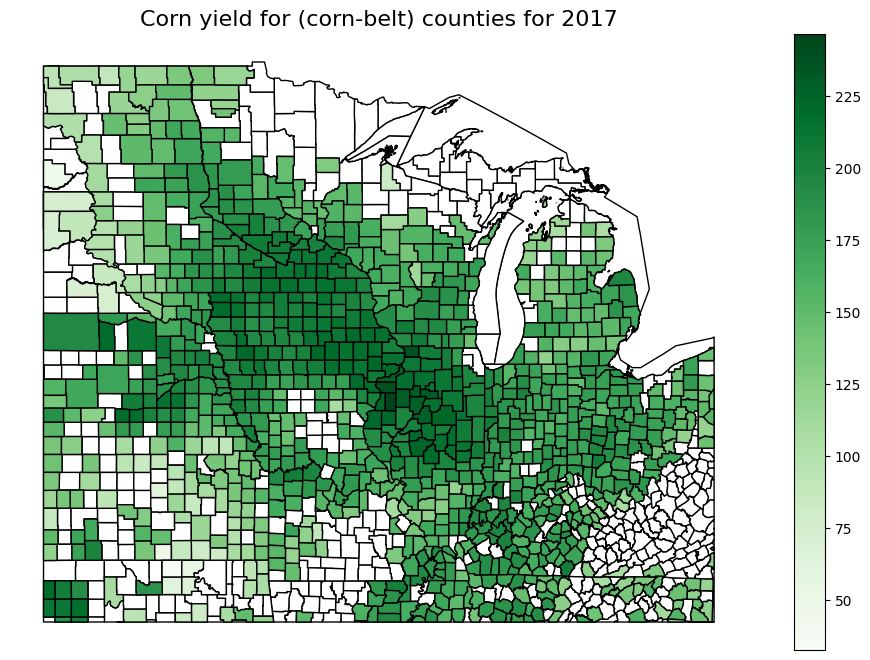

In [214]:
# Load the corrected shapefile
shapefile_path = "/Users/shrey/Downloads/Soil_Land_Crop/datasets/Shape-files/CornBeltShapefiles/CornBeltCounty.shp" 
cbelt_shapefile = gpd.read_file(shapefile_path)

# Ensure the column types are consistent between the shapefile and the dataset
cbelt_shapefile['ID_2'] = cbelt_shapefile['ID_2'].astype(int)  

# Replace 'id2' with the column that matches 'ID_2' in cbelt_shapefile
us_counties_met = cbelt_shapefile.merge(
    gridMET_df_2017, 
    left_on='ID_2',  
    right_on='id2',  
    how='inner'
)

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the shapefile's counties
cbelt_shapefile.plot(ax=ax, color='white', edgecolor='black')

# Overlay the yield data
us_counties_met.plot(
    ax=ax,
    column='yield',  
    cmap = 'Greens',   
    legend=True,
    edgecolor='black'
)

# Add title and labels
plt.title("Corn yield for (corn-belt) counties for 2017", fontsize=16)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

plt.axis('off')
plt.show()

In [228]:
import imageio

# Load the corrected shapefile
shapefile_path = "/Users/shrey/Downloads/Soil_Land_Crop/datasets/Shape-files/CornBeltShapefiles/CornBeltCounty.shp" 
cbelt_shapefile = gpd.read_file(shapefile_path)

# Ensure the column types are consistent between the shapefile and the dataset
cbelt_shapefile['ID_2'] = cbelt_shapefile['ID_2'].astype(int)

# Combine all years' data into one DataFrame
all_years_data = []
for year in range(2004, 2019):  # Assuming your data spans 1980-2018
    yearly_data = gridMET_df[gridMET_df['year'] == year]  # Filter data for the given year
    yearly_data['year'] = year  # Add the year column
    all_years_data.append(yearly_data)

# Combine the data into a single DataFrame
all_years_df = pd.concat(all_years_data, ignore_index=True)

# Merge the shapefile with the full dataset (across all years)
merged_data = cbelt_shapefile.merge(
    all_years_df,
    left_on='ID_2',  # Match 'ID_2' in the shapefile
    right_on='id2',  # Match 'id2' in the dataset
    how='inner'
)

# Ensure geometry is preserved for plotting
merged_data = gpd.GeoDataFrame(merged_data, geometry='geometry')

# Directory to save individual frames
output_dir = "corn_yield_frames"
os.makedirs(output_dir, exist_ok=True)

# Create and save frames for each year
for year in range(2004, 2019):
    fig, ax = plt.subplots(figsize=(12, 8))
    cbelt_shapefile.plot(ax=ax, color="white", edgecolor="black")  # Plot the base shapefile
    merged_data[merged_data['year'] == year].plot(
        ax=ax,
        column='yield',
        cmap='Greens',
        edgecolor='black',
        legend=True
    )
    plt.title(f"Corn Yield for Corn Belt Counties ({year})", fontsize=16)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/corn_yield_{year}.png")
    plt.close()

# Generate the GIF
frames = []
for year in range(2004, 2019):
    frame_path = f"{output_dir}/corn_yield_{year}.png"
    frames.append(imageio.imread(frame_path))

# Save as a looping GIF
gif_path = "corn_yield_animation2.gif"
imageio.mimsave(gif_path, frames, duration = 2.0)  # Adjust duration for speed (0.5 seconds per frame)

print(f"GIF saved at {gif_path}")

/var/folders/19/b_t4kk7x6cs9yr5g7mhxmk1c0000gp/T/ipykernel_16053/1566216340.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly_data['year'] = year  # Add the year column
/var/folders/19/b_t4kk7x6cs9yr5g7mhxmk1c0000gp/T/ipykernel_16053/1566216340.py:56: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(frame_path))


GIF saved at corn_yield_animation2.gif


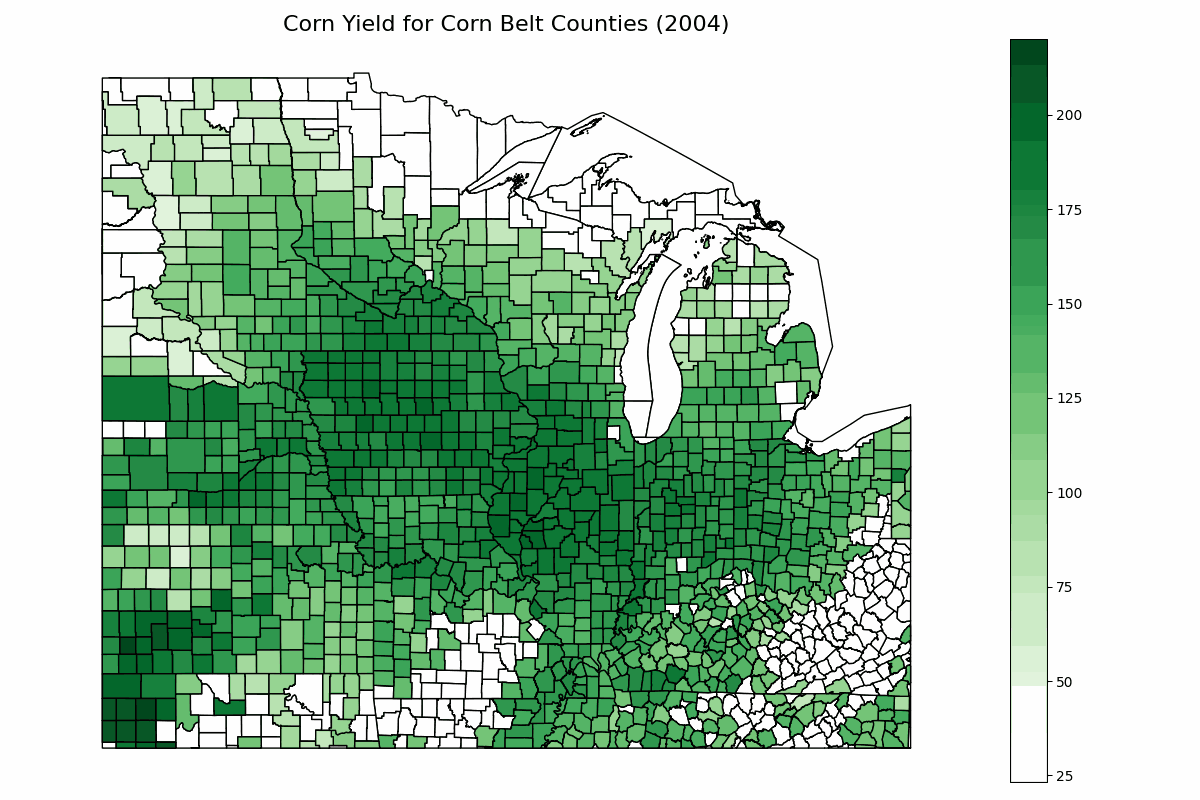

In [227]:
from IPython.display import Image, display

# Path to the GIF file
gif_path = "corn_yield_animation2.gif"

# Display the GIF
display(Image(filename=gif_path))

In [184]:
'''
4 x 4 km grid --> 210 grid cells.
How do you sew together crop yield data for 1366 'units'. Cannot be counties as total are 3144.
The yeild is discrete and not categorical. What does it signify?
How do you plot 210 grid cells data? What are the (lat, lon) for the bounding box?
'''

"\n4 x 4 km grid --> 210 grid cells.\nHow do you sew together crop yield data for 1366 'units'. Cannot be counties as total are 3144.\nThe yeild is discrete and not categorical. What does it signify?\nHow do you plot 210 grid cells data? What are the (lat, lon) for the bounding box?\n"

In [ ]:
################################## Interaction Model Data ##################################

In [86]:
acresplanted_corn_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/ACRESPLANTED_CORN.csv")
flower_corn_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/FLOWER_CORN.csv")
harv_corn_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/HARVESTED_CORN.csv")
pop_corn_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/POPULATION_CORN.csv")
weather1_corn_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/WEATHER_CORN_part1.csv")
weather2_corn_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/WEATHER_CORN_part2.csv")
weather_name_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/Weather_Name.csv")
usda_corn_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/USDAprdictionp_Corn.csv")
progress_corn_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/PROGRESS_CORN.csv")
soil_corn_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/SOIL_CORN.csv")
corn_yield_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/YIELD_CORN.csv")

/var/folders/19/b_t4kk7x6cs9yr5g7mhxmk1c0000gp/T/ipykernel_16053/2962171318.py:5: DtypeWarning: Columns (1,3,5) have mixed types. Specify dtype option on import or set low_memory=False.
  weather1_corn_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/interaction-crop-yield-dataset/WEATHER_CORN_part1.csv")


In [87]:
acresplanted_corn_df = acresplanted_corn_df[['Year', 'State', 'County', 'County ANSI', 'Value']]
flower_corn_df = flower_corn_df.drop(columns=['State ANSI', 'Ag District', 'Ag District Code'])
harv_corn_df = harv_corn_df.drop(columns=['State ANSI', 'Ag District', 'Ag District Code'])
pop_corn_df = pop_corn_df[['Year', 'State', 'County', 'County ANSI', 'Value']]
progress_corn_df = progress_corn_df.drop(columns=['State ANSI', 'Ag District', 'Ag District Code'])
soil_corn_df = soil_corn_df.drop(columns=['State ANSI', 'Ag District', 'Ag District Code'])
usda_corn_df = usda_corn_df.drop(columns=['Period(0)'])
weather1_corn_df = weather1_corn_df.drop(columns=['State ANSI', 'Ag District', 'Ag District Code'])
weather2_corn_df = weather2_corn_df.drop(columns=['State ANSI', 'Ag District', 'Ag District Code'])
corn_yield_df = corn_yield_df[['Year', 'State', 'County', 'County ANSI', 'Value']]

In [85]:
weather_name_df
flower_corn_df
acresplanted_corn_df
flower_corn_df
pop_corn_df
progress_corn_df
weather1_corn_df
weather2_corn_df
usda_corn_df
soil_corn_df
corn_yield_df
harv_corn_df

,Year,State,State ANSI,Ag District,Ag District Code,County,County ANSI,Week 1,Week2,Week 3,...,Week 43,Week 44,Week 45,Week 46,Week 47,Week 48,Week 49,Week 50,Week 51,Week 52
0,2018,ILLINOIS,17,WEST,30,ADAMS,1,0,0,0,...,7,4,3,4,0,0,0,0,0,0
1,2018,ILLINOIS,17,SOUTHWEST,80,ALEXANDER,3,0,0,0,...,7,4,3,4,0,0,0,0,0,0
2,2018,ILLINOIS,17,NORTHEAST,20,BOONE,7,0,0,0,...,7,4,3,4,0,0,0,0,0,0
3,2018,ILLINOIS,17,WEST,30,BROWN,9,0,0,0,...,7,4,3,4,0,0,0,0,0,0
4,2018,ILLINOIS,17,NORTHWEST,10,BUREAU,11,0,0,0,...,7,4,3,4,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11277,1980,IOWA,19,NORTH CENTRAL,20,WINNEBAGO,189,0,0,0,...,20,15,7,13,6,3,0,0,0,0
11278,1980,IOWA,19,NORTHEAST,30,WINNESHIEK,191,0,0,0,...,20,15,7,13,6,3,0,0,0,0
11279,1980,IOWA,19,WEST CENTRAL,40,WOODBURY,193,0,0,0,...,20,15,7,13,6,3,0,0,0,0
11280,1980,IOWA,19,NORTH CENTRAL,20,WORTH,195,0,0,0,...,20,15,7,13,6,3,0,0,0,0


In [ ]:
################################## USDA Data ##################################

In [137]:
usda_corn_2017 = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/USDA_data/Corn/2017/USDA_Corn_County_2017.csv")

In [138]:
usda_corn_2017 = usda_corn_2017[['year', 'state_ansi', 'state_name', 'county_ansi', 'county_name', 'asd_code', 'asd_desc',
        'YIELD, MEASURED IN BU / ACRE']]

In [142]:
st_name = usda_corn_2017['state_name'].unique()
len(st_name)

32

In [91]:
hrrr_ma_2017 = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/WRF_HRRR_data/WRF-HRRR-Computed-Dataset/data/2017/MA/HRRR_25_MA_2017-01.csv")

In [105]:
county_data = hrrr_ma_2017[hrrr_ma_2017["Daily/Monthly"] == "Monthly"]
county_data['Vapor Pressure Deficit (kPa)'] = county_data['Vapor Pressure Deficit (kPa)'].round(2)
county_data = county_data.reset_index(drop=True)

/var/folders/19/b_t4kk7x6cs9yr5g7mhxmk1c0000gp/T/ipykernel_16053/3773888227.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  county_data['Vapor Pressure Deficit (kPa)'] = county_data['Vapor Pressure Deficit (kPa)'].round(2)


In [118]:
county_data

,Year,Month,Day,Daily/Monthly,State,County,FIPS Code,Grid Index,Lat (llcrnr),Lon (llcrnr),...,Max Temperature (K),Min Temperature (K),Precipitation (kg m**-2),Relative Humidity (%),Wind Gust (m s**-1),Wind Speed (m s**-1),U Component of Wind (m s**-1),V Component of Wind (m s**-1),Downward Shortwave Radiation Flux (W m**-2),Vapor Pressure Deficit (kPa)
0,2017,1,NaN,Monthly,MASSACHUSETTS,BARNSTABLE,25001,NaN,NaN,NaN,...,278.760194,273.113468,5.443406,74.033011,7.536324,7.676575,2.007194,0.299098,1436.758957,0.19
1,2017,1,NaN,Monthly,MASSACHUSETTS,BERKSHIRE,25003,NaN,NaN,NaN,...,273.930736,268.157468,4.038662,76.093851,6.958809,3.152464,1.050119,0.060071,1140.395060,0.12
2,2017,1,NaN,Monthly,MASSACHUSETTS,BRISTOL,25005,NaN,NaN,NaN,...,278.293440,271.169722,4.548689,73.748832,6.186396,6.170290,1.767709,-0.003051,1438.756062,0.18
3,2017,1,NaN,Monthly,MASSACHUSETTS,DUKES,25007,NaN,NaN,NaN,...,278.756413,273.781961,6.057658,74.578710,7.866748,7.852510,2.243290,-0.058619,1460.808387,0.19
4,2017,1,NaN,Monthly,MASSACHUSETTS,ESSEX,25009,NaN,NaN,NaN,...,277.912271,270.998704,3.794515,71.230792,6.949826,6.513167,2.115886,0.126859,1572.336804,0.19
5,2017,1,NaN,Monthly,MASSACHUSETTS,FRANKLIN,25011,NaN,NaN,NaN,...,274.870309,268.530306,3.821046,74.131266,5.940232,3.021179,1.180024,0.124882,1353.018859,0.14
6,2017,1,NaN,Monthly,MASSACHUSETTS,HAMPDEN,25013,NaN,NaN,NaN,...,275.954768,269.446946,4.188848,74.912688,5.975557,3.574081,1.247974,-0.066001,1295.966667,0.15
7,2017,1,NaN,Monthly,MASSACHUSETTS,HAMPSHIRE,25015,NaN,NaN,NaN,...,275.412688,268.961944,4.115891,74.763158,5.802394,3.360146,1.246042,-0.017966,1296.726995,0.14
8,2017,1,NaN,Monthly,MASSACHUSETTS,MIDDLESEX,25017,NaN,NaN,NaN,...,277.144647,269.896961,4.012999,73.797849,6.026753,4.900423,1.776728,0.146350,1522.704715,0.17
9,2017,1,NaN,Monthly,MASSACHUSETTS,NORFOLK,25021,NaN,NaN,NaN,...,277.949913,270.725373,4.124698,73.200605,6.154617,5.610690,1.684554,0.112937,1526.836694,0.18


In [121]:
#### Getting single state and single year data

head_dir = "/Users/shrey/Downloads/Soil_Land_Crop/datasets/WRF_HRRR_data"

# Empty list to store dataframes
dataframes = []

# Walk through the directory tree
for root, dirs, files in os.walk(head_dir):
    
    # Check if 'MA' and '2017' are in the path
    if "2017" in root and "MA" in root:
        for file in files:
            if file.endswith(".csv") and "2017" in file :  # Check for CSV files
                file_path = os.path.join(root, file)  # Full file path
                
                # print(f"Reading file: {file_path}")
                
                # Append to the list
                df = pd.read_csv(file_path)
                dataframes.append(df)

ma_df = pd.concat(dataframes, ignore_index=True)

ma_df

,Year,Month,Day,Daily/Monthly,State,County,FIPS Code,Grid Index,Lat (llcrnr),Lon (llcrnr),...,Max Temperature (K),Min Temperature (K),Precipitation (kg m**-2),Relative Humidity (%),Wind Gust (m s**-1),Wind Speed (m s**-1),U Component of Wind (m s**-1),V Component of Wind (m s**-1),Downward Shortwave Radiation Flux (W m**-2),Vapor Pressure Deficit (kPa)
0,2017,3,1.0,Daily,MASSACHUSETTS,BARNSTABLE,25001,0.0,41.513339,-70.6948,...,286.176000,280.759000,2.860000,96.400000,8.157000,9.031000,-0.421000,8.509000,465.700000,0.045000
1,2017,3,2.0,Daily,MASSACHUSETTS,BARNSTABLE,25001,0.0,41.513339,-70.6948,...,284.851000,276.478000,0.057000,62.400000,14.339000,8.846000,6.827000,4.009000,4822.200000,0.438000
2,2017,3,3.0,Daily,MASSACHUSETTS,BARNSTABLE,25001,0.0,41.513339,-70.6948,...,276.217000,270.758000,0.000000,30.200000,8.660000,8.003000,7.953000,-0.595000,4972.700000,0.450000
3,2017,3,4.0,Daily,MASSACHUSETTS,BARNSTABLE,25001,0.0,41.513339,-70.6948,...,273.008000,264.397000,0.000000,32.200000,12.924000,10.918000,9.603000,-3.602000,5007.700000,0.284000
4,2017,3,5.0,Daily,MASSACHUSETTS,BARNSTABLE,25001,0.0,41.513339,-70.6948,...,274.449000,261.123000,0.000000,26.400000,12.151000,11.093000,8.702000,-6.840000,5191.200000,0.303000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123521,2017,9,NaN,Monthly,MASSACHUSETTS,MIDDLESEX,25017,NaN,NaN,NaN,...,296.913608,287.464857,2.896886,77.247265,5.019225,4.125720,0.887249,-1.141141,3667.891632,0.559084
123522,2017,9,NaN,Monthly,MASSACHUSETTS,NORFOLK,25021,NaN,NaN,NaN,...,296.900338,287.742098,2.856035,77.881458,5.374140,4.873781,0.829956,-1.252848,3676.719458,0.550635
123523,2017,9,NaN,Monthly,MASSACHUSETTS,PLYMOUTH,25023,NaN,NaN,NaN,...,296.084438,288.230685,3.446197,80.912069,5.862525,5.971457,0.790767,-1.256408,3650.192069,0.457592
123524,2017,9,NaN,Monthly,MASSACHUSETTS,SUFFOLK,25025,NaN,NaN,NaN,...,296.442800,287.941000,2.872933,82.393333,4.861800,5.370767,0.925533,-1.262733,3617.323333,0.432600


In [122]:
#### Getting all state and single year data

head_dir = "/Users/shrey/Downloads/Soil_Land_Crop/datasets/WRF_HRRR_data"

# Empty list to store dataframes
dataframes = []

# Walk through the directory tree
for root, dirs, files in os.walk(head_dir):
    
    # Check if 'MA' and '2017' are in the path
    if "2017" in root:
        for file in files:
            if file.endswith(".csv") and "2017" in file :  # Check for CSV files
                file_path = os.path.join(root, file)  # Full file path
                
                # print(f"Reading file: {file_path}")
                
                # Append to the list
                df = pd.read_csv(file_path)
                dataframes.append(df)

us_hrrr_df = pd.concat(dataframes, ignore_index=True)

us_hrrr_df

,Year,Month,Day,Daily/Monthly,State,County,FIPS Code,Grid Index,Lat (llcrnr),Lon (llcrnr),...,Max Temperature (K),Min Temperature (K),Precipitation (kg m**-2),Relative Humidity (%),Wind Gust (m s**-1),Wind Speed (m s**-1),U Component of Wind (m s**-1),V Component of Wind (m s**-1),Downward Shortwave Radiation Flux (W m**-2),Vapor Pressure Deficit (kPa)
0,2017,7,1.0,Daily,FLORIDA,ALACHUA,12001,0.0,29.431764,-82.658554,...,305.565000,295.687000,1.660000,82.900000,3.530000,3.708000,0.641000,2.303000,6425.500000,0.698000
1,2017,7,2.0,Daily,FLORIDA,ALACHUA,12001,0.0,29.431764,-82.658554,...,305.902000,296.470000,0.000000,78.600000,3.034000,3.093000,1.952000,1.618000,6673.500000,0.934000
2,2017,7,3.0,Daily,FLORIDA,ALACHUA,12001,0.0,29.431764,-82.658554,...,305.308000,294.950000,15.180000,81.400000,4.195000,3.296000,2.422000,0.688000,5184.900000,0.773000
3,2017,7,4.0,Daily,FLORIDA,ALACHUA,12001,0.0,29.431764,-82.658554,...,306.319000,296.550000,0.000000,79.200000,2.296000,2.285000,1.539000,0.922000,6520.500000,0.917000
4,2017,7,5.0,Daily,FLORIDA,ALACHUA,12001,0.0,29.431764,-82.658554,...,308.230000,296.040000,3.038000,77.500000,3.466000,2.932000,0.320000,1.221000,6432.700000,0.963000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36921291,2017,5,NaN,Monthly,GEORGIA,WHITFIELD,13313,NaN,NaN,NaN,...,299.303992,287.746915,9.421738,75.451613,4.456883,1.928633,0.479149,0.613867,5519.168984,0.700621
36921292,2017,5,NaN,Monthly,GEORGIA,WILCOX,13315,NaN,NaN,NaN,...,302.696668,290.548488,4.816387,65.903687,4.772719,3.380945,1.146286,1.142442,5751.347959,1.157613
36921293,2017,5,NaN,Monthly,GEORGIA,WILKES,13317,NaN,NaN,NaN,...,301.260574,289.925136,5.939076,69.888479,4.913578,2.250016,1.127217,0.873177,6016.064548,0.939578
36921294,2017,5,NaN,Monthly,GEORGIA,WILKINSON,13319,NaN,NaN,NaN,...,301.997824,289.544628,6.392426,67.072043,4.426981,2.648600,0.892422,0.740613,5869.354656,1.071751


In [143]:
us_hrrr_df.columns

Index(['Year', 'Month', 'Day', 'Daily/Monthly', 'State', 'County', 'FIPS Code',
       'Grid Index', 'Lat (llcrnr)', 'Lon (llcrnr)', 'Lat (urcrnr)',
       'Lon (urcrnr)', 'Avg Temperature (K)', 'Max Temperature (K)',
       'Min Temperature (K)', 'Precipitation (kg m**-2)',
       'Relative Humidity (%)', 'Wind Gust (m s**-1)', 'Wind Speed (m s**-1)',
       'U Component of Wind (m s**-1)', 'V Component of Wind (m s**-1)',
       'Downward Shortwave Radiation Flux (W m**-2)',
       'Vapor Pressure Deficit (kPa)'],
      dtype='object')

In [124]:
state_uq = us_hrrr_df['State'].unique()
len(state_uq)

48

In [125]:
us_county_monthly = us_hrrr_df[us_hrrr_df["Daily/Monthly"] == "Monthly"]
us_county_monthly['Vapor Pressure Deficit (kPa)'] = us_county_monthly['Vapor Pressure Deficit (kPa)'].round(2)
us_county_monthly = us_county_monthly.reset_index(drop=True)

/var/folders/19/b_t4kk7x6cs9yr5g7mhxmk1c0000gp/T/ipykernel_16053/1111503723.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  us_county_monthly['Vapor Pressure Deficit (kPa)'] = us_county_monthly['Vapor Pressure Deficit (kPa)'].round(2)


In [126]:
us_county_monthly

,Year,Month,Day,Daily/Monthly,State,County,FIPS Code,Grid Index,Lat (llcrnr),Lon (llcrnr),...,Max Temperature (K),Min Temperature (K),Precipitation (kg m**-2),Relative Humidity (%),Wind Gust (m s**-1),Wind Speed (m s**-1),U Component of Wind (m s**-1),V Component of Wind (m s**-1),Downward Shortwave Radiation Flux (W m**-2),Vapor Pressure Deficit (kPa)
0,2017,7,NaN,Monthly,FLORIDA,ALACHUA,12001,NaN,NaN,NaN,...,305.151911,295.665832,14.012409,82.760512,3.428076,3.648462,0.409882,1.235248,5424.304338,0.71
1,2017,7,NaN,Monthly,FLORIDA,BAKER,12003,NaN,NaN,NaN,...,305.830331,296.228013,8.504727,80.868602,3.560854,3.666441,0.771688,1.555073,5406.323871,0.82
2,2017,7,NaN,Monthly,FLORIDA,BAY,12005,NaN,NaN,NaN,...,304.313310,296.966351,13.924408,80.822373,3.277433,3.478563,1.472915,0.799631,5632.893965,0.77
3,2017,7,NaN,Monthly,FLORIDA,BRADFORD,12007,NaN,NaN,NaN,...,305.080466,296.007473,13.029573,82.746237,3.602194,3.684000,0.488864,1.500057,5558.335125,0.72
4,2017,7,NaN,Monthly,FLORIDA,BREVARD,12009,NaN,NaN,NaN,...,304.905337,297.260890,12.016297,80.816774,4.149537,4.792045,-1.426890,2.568806,5949.621048,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35851,2017,5,NaN,Monthly,GEORGIA,WHITFIELD,13313,NaN,NaN,NaN,...,299.303992,287.746915,9.421738,75.451613,4.456883,1.928633,0.479149,0.613867,5519.168984,0.70
35852,2017,5,NaN,Monthly,GEORGIA,WILCOX,13315,NaN,NaN,NaN,...,302.696668,290.548488,4.816387,65.903687,4.772719,3.380945,1.146286,1.142442,5751.347959,1.16
35853,2017,5,NaN,Monthly,GEORGIA,WILKES,13317,NaN,NaN,NaN,...,301.260574,289.925136,5.939076,69.888479,4.913578,2.250016,1.127217,0.873177,6016.064548,0.94
35854,2017,5,NaN,Monthly,GEORGIA,WILKINSON,13319,NaN,NaN,NaN,...,301.997824,289.544628,6.392426,67.072043,4.426981,2.648600,0.892422,0.740613,5869.354656,1.07


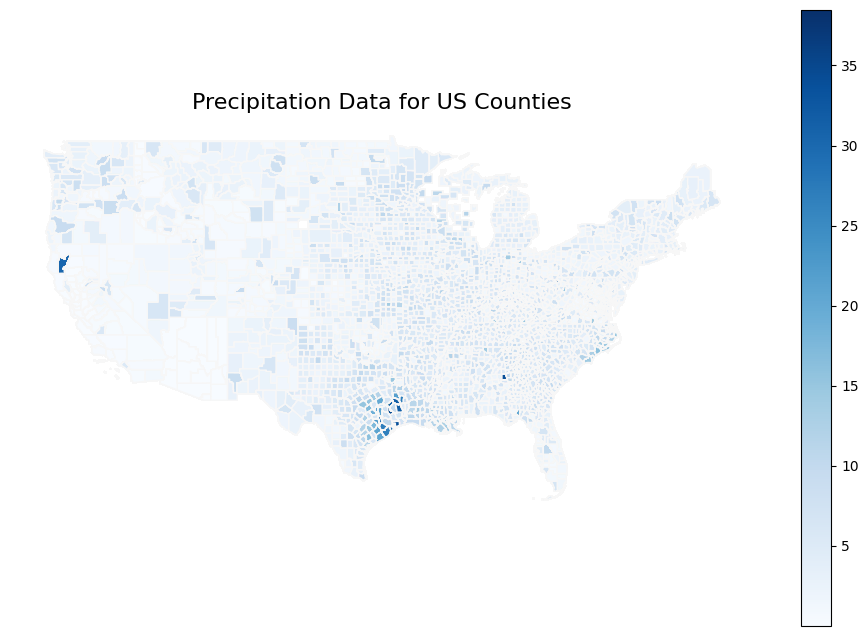

In [208]:
# Load the US county shapefile
shapefile_path = "/Users/shrey/Downloads/Soil_Land_Crop/datasets/Shape-files/cb_2018_us_county_5m/cb_2018_us_county_5m.shp"
us_shapefile = gpd.read_file(shapefile_path)

conterminous_us = us_shapefile[~us_shapefile['STATEFP'].isin(['02', '15', '72', '66', '78', '60', '69'])]

# "County" column matches the county names in the shapefile
us_counties_met = conterminous_us.merge(
    us_county_monthly, 
    left_on = conterminous_us['NAME'].str.lower(), 
    right_on = us_county_monthly['County'].str.lower(), 
    how = 'inner'
)

fig, ax = plt.subplots(figsize=(12, 8))

us_counties_met.plot(
    ax = ax,
    column = 'Precipitation (kg m**-2)',  # Column to color by
    cmap = 'Blues',  # Choose a colormap
    legend = True,  # Add a legend
    edgecolor = '#f7f7f7'
)

plt.title("Precipitation Data for US Counties", fontsize=16)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

plt.axis('off')

# plt.tight_layout()
plt.show()

In [145]:
##### Crop yield and Meteorological Data
usda_corn_2017['county_name'] = usda_corn_2017['county_name'].str.lower()
us_hrrr_df['County'] = us_hrrr_df['County'].str.lower()

merged_data = pd.merge(usda_corn_2017, us_hrrr_df, left_on='county_name', right_on='County', how='inner')

In [149]:
merged_data.columns

Index(['year', 'state_ansi', 'state_name', 'county_ansi', 'county_name',
       'asd_code', 'asd_desc', 'YIELD, MEASURED IN BU / ACRE', 'Year', 'Month',
       'Day', 'Daily/Monthly', 'State', 'County', 'FIPS Code', 'Grid Index',
       'Lat (llcrnr)', 'Lon (llcrnr)', 'Lat (urcrnr)', 'Lon (urcrnr)',
       'Avg Temperature (K)', 'Max Temperature (K)', 'Min Temperature (K)',
       'Precipitation (kg m**-2)', 'Relative Humidity (%)',
       'Wind Gust (m s**-1)', 'Wind Speed (m s**-1)',
       'U Component of Wind (m s**-1)', 'V Component of Wind (m s**-1)',
       'Downward Shortwave Radiation Flux (W m**-2)',
       'Vapor Pressure Deficit (kPa)'],
      dtype='object')

In [150]:
vals = merged_data['state_name'].unique()
len(vals)

32

In [107]:
unique_fips_codes = county_data['FIPS Code'].unique()
unique_fips_codes

[25001 25003 25005 25007 25009 25011 25013 25015 25017 25021 25023 25025
 25027]


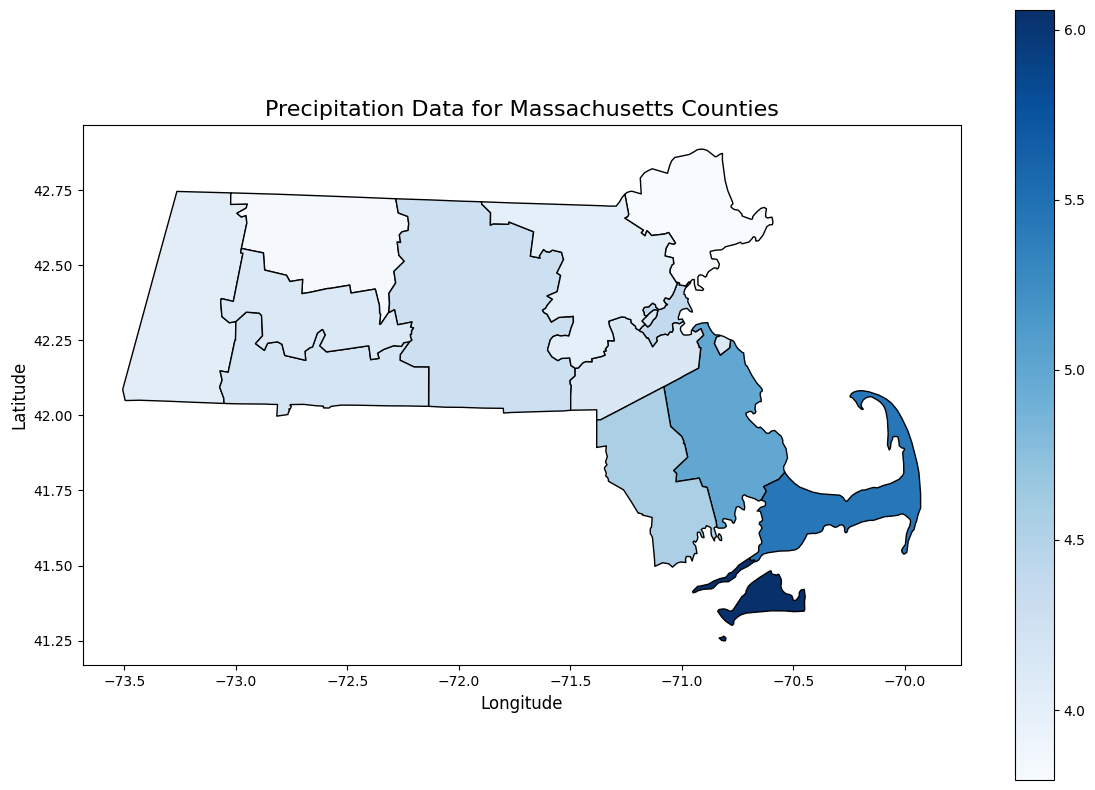

In [116]:
# Load the US county shapefile
shapefile_path = "/Users/shrey/Downloads/Soil_Land_Crop/datasets/Shape-files/cb_2018_us_county_5m/cb_2018_us_county_5m.shp"
us_shapefile = gpd.read_file(shapefile_path)

# Filter the shapefile to keep only Massachusetts counties
ma_counties = us_shapefile[us_shapefile['STATEFP'] == '25']

# "County" column matches the county names in the shapefile
ma_counties = ma_counties.merge(
    county_data, 
    left_on=ma_counties['NAME'].str.lower(), 
    right_on=county_data['County'].str.lower(), 
    how='inner'
)

fig, ax = plt.subplots(figsize=(12, 8))

ma_counties.plot(
    ax=ax,
    column='Precipitation (kg m**-2)',  # Column to color by
    cmap='Blues',  # Choose a colormap
    legend=True,  # Add a legend
    edgecolor='black'
)

plt.title("Precipitation Data for Massachusetts Counties", fontsize=16)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
##################### Try Regression #####################

In [4]:
gridMET_hz_data = pd.read_csv("/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/gridMET.csv")

In [5]:
gridMET_hz_data

,id2,year,yield,tmmx-10-04,tmmx-11-04,tmmx-12-04,tmmx-13-04,tmmx-14-04,tmmx-15-04,tmmx-16-04,...,th-27-10,th-28-10,th-29-10,th-30-10,th-31-10,th-01-11,th-02-11,th-03-11,th-04-11,th-05-11
0,112,1980,27.0,297.150746,288.676866,286.200000,282.085821,294.295522,296.445522,294.279851,...,336.291045,29.574627,244.283582,224.067164,221.201493,212.723881,228.544776,302.686567,259.014925,211.365672
1,113,1980,28.0,297.274444,288.907778,285.003333,280.973333,293.290000,294.762222,293.843333,...,328.100000,297.333333,281.933333,246.333333,243.800000,211.500000,227.733333,295.566667,279.533333,198.266667
2,119,1980,29.0,295.384158,290.352475,283.873267,281.912871,292.167327,292.957426,295.866337,...,350.772277,14.564356,353.693069,225.841584,230.623762,150.069307,194.930693,289.900990,305.217822,175.801980
3,120,1980,28.0,296.932727,290.636364,282.992727,282.347273,293.369091,295.369091,294.618182,...,321.109091,9.345455,344.872727,248.000000,249.872727,212.509091,215.654545,312.745455,312.200000,187.600000
4,124,1980,24.0,295.936275,290.024510,283.841176,282.185294,292.311765,294.537255,296.009804,...,333.196078,13.196078,326.127451,219.882353,219.745098,176.735294,192.009804,290.950980,307.000000,169.245098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45333,3121,2018,182.0,287.481818,288.018182,277.063636,275.174747,273.435354,273.714141,276.369697,...,247.565657,216.000000,160.353535,303.808081,163.747475,207.292929,150.959596,68.696970,143.525253,222.484848
45334,3122,2018,156.8,283.802586,280.986207,276.347414,272.293966,270.118966,273.640517,276.302586,...,195.543103,217.198276,169.939655,286.482759,157.887931,252.327586,141.724138,73.000000,160.353448,229.103448
45335,3123,2018,163.4,284.855263,282.180702,276.589474,272.520175,269.822807,273.605263,276.004386,...,237.815789,212.184211,173.289474,289.824561,164.131579,210.991228,108.508772,78.728070,156.833333,231.228070
45336,3124,2018,160.4,283.798990,281.497980,276.852525,272.847475,270.563636,274.037374,276.393939,...,197.636364,215.575758,158.484848,288.727273,155.878788,226.848485,175.696970,68.757576,153.909091,228.757576


In [6]:
meta_cols = ['id2', 'year', 'yield']
ts_cols = [col for col in gridMET_hz_data.columns if col not in meta_cols]

In [9]:
meta_cols, len(ts_cols)

(['id2', 'year', 'yield'], 3360)

In [11]:
from collections import defaultdict

contents = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs', 'th',
            'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']

grouped_features = defaultdict(list)

for col in gridMET_hz_data.columns:
    for prefix in contents:
        if col.startswith(prefix + '-'):
            grouped_features[prefix].append(col)

In [16]:
def extract_summary_stats(df, columns, prefix):
    sub_df = df[columns]
    stats = pd.DataFrame()
    stats[f'{prefix}_mean'] = sub_df.mean(axis=1)
    stats[f'{prefix}_std'] = sub_df.std(axis=1)
    stats[f'{prefix}_min'] = sub_df.min(axis=1)
    stats[f'{prefix}_max'] = sub_df.max(axis=1)
    stats[f'{prefix}_25q'] = sub_df.quantile(0.25, axis=1)
    stats[f'{prefix}_50q'] = sub_df.quantile(0.50, axis=1)
    stats[f'{prefix}_75q'] = sub_df.quantile(0.75, axis=1)
    stats[f'{prefix}_skew'] = sub_df.skew(axis=1)
    stats[f'{prefix}_kurt'] = sub_df.kurt(axis=1)
    return stats

In [17]:
feature_stats_list = [extract_summary_stats(gridMET_hz_data, cols, prefix) for prefix, cols in grouped_features.items()]
features_reduced = pd.concat(feature_stats_list, axis=1)

In [18]:
features_reduced

,tmmx_mean,tmmx_std,tmmx_min,tmmx_max,tmmx_25q,tmmx_50q,tmmx_75q,tmmx_skew,tmmx_kurt,rmax_mean,...,tmmn_kurt,th_mean,th_std,th_min,th_max,th_25q,th_50q,th_75q,th_skew,th_kurt
0,302.547299,7.327733,282.085821,314.003731,296.794776,303.152239,308.860075,-0.541945,-0.390780,88.534865,...,-0.669303,182.028998,72.071924,5.649254,341.000000,156.936567,194.977612,212.587687,-0.354084,0.173237
1,302.068878,7.265812,280.973333,314.323333,296.825278,303.063333,308.381944,-0.534341,-0.469318,85.865079,...,-0.656814,192.143968,73.244106,3.833333,353.366667,150.333333,201.500000,230.516667,-0.280678,-0.160928
2,303.100471,7.510462,281.912871,315.000990,297.746782,304.330198,309.199505,-0.536117,-0.486756,91.763880,...,-0.771025,178.083970,88.493475,4.910891,353.693069,107.799505,196.945545,229.722772,-0.219048,-0.707983
3,302.966961,7.415510,282.347273,314.692727,297.284091,303.875455,309.279545,-0.443255,-0.611860,88.569844,...,-0.668782,192.123030,80.973207,5.000000,354.654545,153.363636,208.618182,237.704545,-0.487851,-0.251575
4,303.312180,7.452360,282.185294,315.190196,298.059069,304.456863,309.444363,-0.558705,-0.501059,89.555033,...,-0.713228,176.449627,85.664170,4.823529,344.705882,115.848039,197.436275,221.125000,-0.361921,-0.561712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45333,294.953877,7.903960,273.435354,307.487879,288.758586,296.868182,301.115909,-0.699714,-0.391129,95.237614,...,-0.748074,174.472102,74.599764,20.898990,325.585859,115.785354,177.520202,230.707071,-0.016760,-0.947121
45334,294.790673,8.390165,270.118966,308.180172,288.875647,297.051293,301.053879,-0.759059,-0.312795,93.421281,...,-0.870394,182.414943,74.370123,26.836207,317.560345,117.767241,195.073276,243.765086,-0.132563,-1.141658
45335,294.716057,8.376341,269.822807,308.200877,288.603947,296.722807,300.911404,-0.759404,-0.276751,92.840480,...,-0.800352,181.480117,76.066105,26.561404,317.333333,113.414474,188.328947,245.151316,-0.125809,-1.122236
45336,294.695984,8.227454,270.563636,307.890909,288.658081,296.950505,300.931061,-0.740544,-0.339646,90.952795,...,-0.841316,179.765945,70.162284,27.787879,314.848485,122.719697,184.712121,234.174242,-0.078467,-0.955658


In [19]:
features_reduced['id2'] = gridMET_hz_data['id2']
features_reduced['year'] = gridMET_hz_data['year']
features_reduced['yield'] = gridMET_hz_data['yield']

In [20]:
features_reduced

,tmmx_mean,tmmx_std,tmmx_min,tmmx_max,tmmx_25q,tmmx_50q,tmmx_75q,tmmx_skew,tmmx_kurt,rmax_mean,...,th_min,th_max,th_25q,th_50q,th_75q,th_skew,th_kurt,id2,year,yield
0,302.547299,7.327733,282.085821,314.003731,296.794776,303.152239,308.860075,-0.541945,-0.390780,88.534865,...,5.649254,341.000000,156.936567,194.977612,212.587687,-0.354084,0.173237,112,1980,27.0
1,302.068878,7.265812,280.973333,314.323333,296.825278,303.063333,308.381944,-0.534341,-0.469318,85.865079,...,3.833333,353.366667,150.333333,201.500000,230.516667,-0.280678,-0.160928,113,1980,28.0
2,303.100471,7.510462,281.912871,315.000990,297.746782,304.330198,309.199505,-0.536117,-0.486756,91.763880,...,4.910891,353.693069,107.799505,196.945545,229.722772,-0.219048,-0.707983,119,1980,29.0
3,302.966961,7.415510,282.347273,314.692727,297.284091,303.875455,309.279545,-0.443255,-0.611860,88.569844,...,5.000000,354.654545,153.363636,208.618182,237.704545,-0.487851,-0.251575,120,1980,28.0
4,303.312180,7.452360,282.185294,315.190196,298.059069,304.456863,309.444363,-0.558705,-0.501059,89.555033,...,4.823529,344.705882,115.848039,197.436275,221.125000,-0.361921,-0.561712,124,1980,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45333,294.953877,7.903960,273.435354,307.487879,288.758586,296.868182,301.115909,-0.699714,-0.391129,95.237614,...,20.898990,325.585859,115.785354,177.520202,230.707071,-0.016760,-0.947121,3121,2018,182.0
45334,294.790673,8.390165,270.118966,308.180172,288.875647,297.051293,301.053879,-0.759059,-0.312795,93.421281,...,26.836207,317.560345,117.767241,195.073276,243.765086,-0.132563,-1.141658,3122,2018,156.8
45335,294.716057,8.376341,269.822807,308.200877,288.603947,296.722807,300.911404,-0.759404,-0.276751,92.840480,...,26.561404,317.333333,113.414474,188.328947,245.151316,-0.125809,-1.122236,3123,2018,163.4
45336,294.695984,8.227454,270.563636,307.890909,288.658081,296.950505,300.931061,-0.740544,-0.339646,90.952795,...,27.787879,314.848485,122.719697,184.712121,234.174242,-0.078467,-0.955658,3124,2018,160.4


In [23]:
df_yield = gridMET_hz_data[['id2', 'year', 'yield']].sort_values(['id2', 'year'])

df_yield['yield_prev_year'] = df_yield.groupby('id2')['yield'].shift(1)
df_yield['yield_5yr_mean'] = df_yield.groupby('id2')['yield'].shift(1).rolling(5, min_periods=1).mean().reset_index(0, drop=True)
df_yield['yield_min'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().min())
df_yield['yield_max'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().max())
df_yield['yield_std'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().std())
df_yield['yield_mean'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().mean())

In [24]:
df_yield

,id2,year,yield,yield_prev_year,yield_5yr_mean,yield_min,yield_max,yield_std,yield_mean
2631,111,1982,87.0,NaN,148.18,NaN,NaN,NaN,NaN
0,112,1980,27.0,NaN,NaN,NaN,NaN,NaN,NaN
1302,112,1981,63.0,27.0,132.75,27.0,27.0,NaN,27.000000
2632,112,1982,73.0,63.0,144.44,27.0,63.0,25.455844,45.000000
3950,112,1983,60.0,73.0,85.20,27.0,73.0,24.193663,54.333333
...,...,...,...,...,...,...,...,...,...
41504,3125,2014,148.6,98.5,109.00,66.9,150.0,20.956832,111.929412
42463,3125,2015,144.0,148.6,75.75,66.9,150.0,21.556725,112.977143
43457,3125,2016,157.1,144.0,78.44,66.9,150.0,21.866625,113.838889
44458,3125,2017,138.5,157.1,90.86,66.9,157.1,22.703504,115.008108


In [25]:
final_df = features_reduced.merge(df_yield.drop(columns='yield'), on=['id2', 'year'], how='left')

In [26]:
final_df

,tmmx_mean,tmmx_std,tmmx_min,tmmx_max,tmmx_25q,tmmx_50q,tmmx_75q,tmmx_skew,tmmx_kurt,rmax_mean,...,th_kurt,id2,year,yield,yield_prev_year,yield_5yr_mean,yield_min,yield_max,yield_std,yield_mean
0,302.547299,7.327733,282.085821,314.003731,296.794776,303.152239,308.860075,-0.541945,-0.390780,88.534865,...,0.173237,112,1980,27.0,NaN,NaN,NaN,NaN,NaN,NaN
1,302.068878,7.265812,280.973333,314.323333,296.825278,303.063333,308.381944,-0.534341,-0.469318,85.865079,...,-0.160928,113,1980,28.0,NaN,NaN,NaN,NaN,NaN,NaN
2,303.100471,7.510462,281.912871,315.000990,297.746782,304.330198,309.199505,-0.536117,-0.486756,91.763880,...,-0.707983,119,1980,29.0,NaN,27.000000,NaN,NaN,NaN,NaN
3,302.966961,7.415510,282.347273,314.692727,297.284091,303.875455,309.279545,-0.443255,-0.611860,88.569844,...,-0.251575,120,1980,28.0,NaN,45.000000,NaN,NaN,NaN,NaN
4,303.312180,7.452360,282.185294,315.190196,298.059069,304.456863,309.444363,-0.558705,-0.501059,89.555033,...,-0.561712,124,1980,24.0,NaN,54.333333,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45333,294.953877,7.903960,273.435354,307.487879,288.758586,296.868182,301.115909,-0.699714,-0.391129,95.237614,...,-0.947121,3121,2018,182.0,181.5,125.940000,53.3,181.5,27.612252,124.876316
45334,294.790673,8.390165,270.118966,308.180172,288.875647,297.051293,301.053879,-0.759059,-0.312795,93.421281,...,-1.141658,3122,2018,156.8,165.7,127.860000,74.1,165.7,21.031809,121.163158
45335,294.716057,8.376341,269.822807,308.200877,288.603947,296.722807,300.911404,-0.759404,-0.276751,92.840480,...,-1.122236,3123,2018,163.4,161.5,129.760000,78.2,182.8,24.703348,124.039474
45336,294.695984,8.227454,270.563636,307.890909,288.658081,296.950505,300.931061,-0.740544,-0.339646,90.952795,...,-0.955658,3124,2018,160.4,164.0,131.560000,62.1,164.0,23.261209,119.194595
